<p><img alt="UdeA logo" style="height: 180px !important; width: auto;" src="https://upload.wikimedia.org/wikipedia/commons/archive/f/fb/20161010213812%21Escudo-UdeA.svg" align="right" hspace="10px" vspace="0px"></p>


<h1> <b>Laboratorio 01 pinguinos

Física Computacional II 2026-2</b> </h1>

</div>

<!-- <br> le permite hacer espacios -->
<br>

<hr size=10 noshade color="green">
<p>


<div align="left">       

<h3><i><b>Felipe Quitian Gallego</b><br>  
Universidad de Antioquia <br>
Instituto de Física  <br>
</i></h3>
</div>

## Librerias

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as sp_stats

## Parte A

In [2]:
# Punto 1
# Cargamos el dataset en un DataFrame
df = sns.load_dataset('penguins')

# Calculamos el numero de filas y columnas
dimensiones = df.shape
print(f"Filas: {dimensiones[0]}, Columnas: {dimensiones[1]}")

Filas: 344, Columnas: 7


In [3]:
# Punto 2
# Vemos cuales variables son numericas y cuales son categoricas
print(df.dtypes)

species               object
island                object
bill_length_mm       float64
bill_depth_mm        float64
flipper_length_mm    float64
body_mass_g          float64
sex                   object
dtype: object


In [4]:
# Punto 3
# Calculamos cuantos valores faltantes hay por columna
faltantes = df.isnull().sum()
print(faltantes)

species               0
island                0
bill_length_mm        2
bill_depth_mm         2
flipper_length_mm     2
body_mass_g           2
sex                  11
dtype: int64


In [5]:
# Punto 4
# Verificamos si existen filas duplicadas
duplicados = df.duplicated().sum()
print(f"Filas duplicadas: {duplicados}")

Filas duplicadas: 0


In [6]:
# Punto 5
# Calculamos la cardinalidad de las variables
cardinalidad = df.nunique()
print(cardinalidad)

species                3
island                 3
bill_length_mm       164
bill_depth_mm         80
flipper_length_mm     55
body_mass_g           94
sex                    2
dtype: int64


Las variables con baja cardinalidad son species, island y sex.

## Parte B

In [7]:
# Punto 6
# Filtramos las variables numericas
numericas = df.select_dtypes(include=['float64'])

# Calculamos los valores estadisticos y transponemos para que queden como columnas
stats = numericas.describe().T

# Calculamos el Rango Intercuartílico (IQR = Q3 - Q1)
stats['IQR'] = stats['75%'] - stats['25%']

# Calculamos la media, mediana, desviación estándar y el rango intercuartílico
resultados_num = stats[['mean', '50%', 'std', 'IQR']]
print(resultados_num)

                          mean      50%         std       IQR
bill_length_mm       43.921930    44.45    5.459584     9.275
bill_depth_mm        17.151170    17.30    1.974793     3.100
flipper_length_mm   200.915205   197.00   14.061714    23.000
body_mass_g        4201.754386  4050.00  801.954536  1200.000


In [8]:
# Punto 7
# Filtramos las variables categoricas
categoricas = df.select_dtypes(include=['object'])

# Calculamos los conteos y los porcentajes para cada variable
for columna in categoricas.columns:
    conteos = df[columna].value_counts()
    porcentajes = df[columna].value_counts(normalize=True) * 100

    # Imprimimos ambos resultados en forma de DataFrame
    resumen_cat = pd.DataFrame({'Conteo': conteos, 'Porcentaje (%)': porcentajes})
    print(f"\nResumen para {columna}:")
    print(resumen_cat)


Resumen para species:
           Conteo  Porcentaje (%)
species                          
Adelie        152       44.186047
Gentoo        124       36.046512
Chinstrap      68       19.767442

Resumen para island:
           Conteo  Porcentaje (%)
island                           
Biscoe        168       48.837209
Dream         124       36.046512
Torgersen      52       15.116279

Resumen para sex:
        Conteo  Porcentaje (%)
sex                           
Male       168        50.45045
Female     165        49.54955


In [9]:
# Punto 8
# Tabla de contingencia entre Especie e Isla
tabla_cruzada = pd.crosstab(df['species'], df['island'])
print("\nTabla cruzada (Especie vs Isla):")
print(tabla_cruzada)


Tabla cruzada (Especie vs Isla):
island     Biscoe  Dream  Torgersen
species                            
Adelie         44     56         52
Chinstrap       0     68          0
Gentoo        124      0          0


In [10]:
# Punto 9
# Matrices de correlacion
# Pearson (Relación lineal)
matriz_pearson = numericas.corr(method='pearson')
print("\nMatriz de correlación (Pearson):")
print(matriz_pearson)

# Spearman (Relación monótona)
matriz_spearman = numericas.corr(method='spearman')
print("\nMatriz de correlación (Spearman):")
print(matriz_spearman)


Matriz de correlación (Pearson):
                   bill_length_mm  bill_depth_mm  flipper_length_mm  \
bill_length_mm           1.000000      -0.235053           0.656181   
bill_depth_mm           -0.235053       1.000000          -0.583851   
flipper_length_mm        0.656181      -0.583851           1.000000   
body_mass_g              0.595110      -0.471916           0.871202   

                   body_mass_g  
bill_length_mm        0.595110  
bill_depth_mm        -0.471916  
flipper_length_mm     0.871202  
body_mass_g           1.000000  

Matriz de correlación (Spearman):
                   bill_length_mm  bill_depth_mm  flipper_length_mm  \
bill_length_mm           1.000000      -0.221749           0.672772   
bill_depth_mm           -0.221749       1.000000          -0.523267   
flipper_length_mm        0.672772      -0.523267           1.000000   
body_mass_g              0.583800      -0.432372           0.839974   

                   body_mass_g  
bill_length_mm       

## Parte C

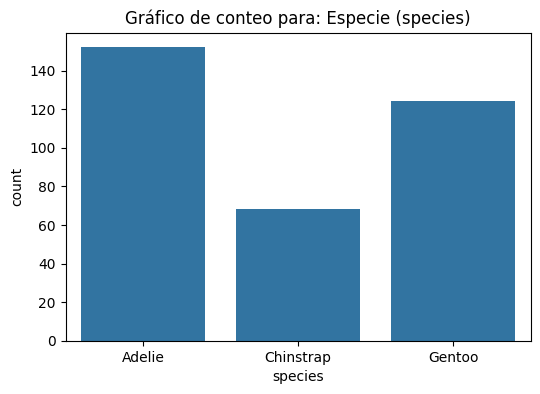

In [11]:
# Punto 10
# Generamos el histograma para especie
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='species')
plt.title('Gráfico de conteo para: Especie (species)')
plt.show()

El histograma de especie presenta una distribución de clases desbalanceada. Mostrando que la especie mas comun es Adelie, con una frecuencia cercana a 150, seguida de Gentoo con más de 120 individuos, y finalmente Chinstrap es la especie menos comun, con algo menos de 70 registros

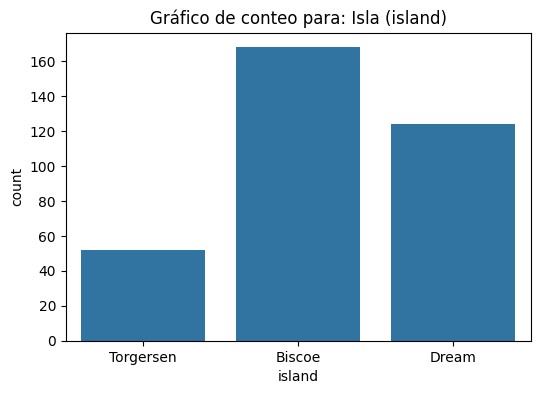

In [12]:
# Histograma para Isla
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='island')
plt.title('Gráfico de conteo para: Isla (island)')
plt.show()

El histograma de islas muestra una diferencia muy grande entre las islas. En la isla Biscoe es donde hay la mayor cantidad de observaciones, superando las 160, seguida por la isla Dream con poco más de 120. Se observa que en la isla Torgersen hay una tasa de observacion mucho menor comparada con las otras dos islas, con un conteo cercano a 50.

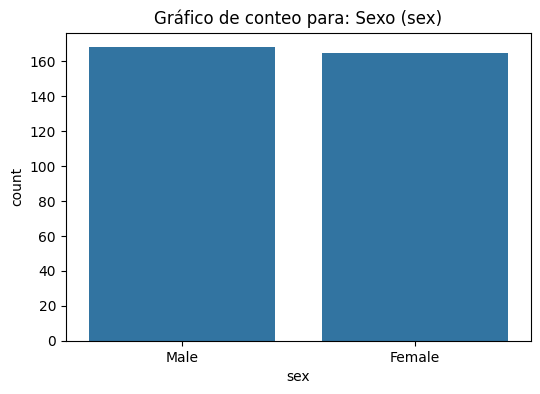

In [13]:
# Histrograma para sexo
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='sex')
plt.title('Gráfico de conteo para: Sexo (sex)')
plt.show()

El histograma sobre sexo nos muestra que la distribución entre machos y hembras es prácticamente igual.

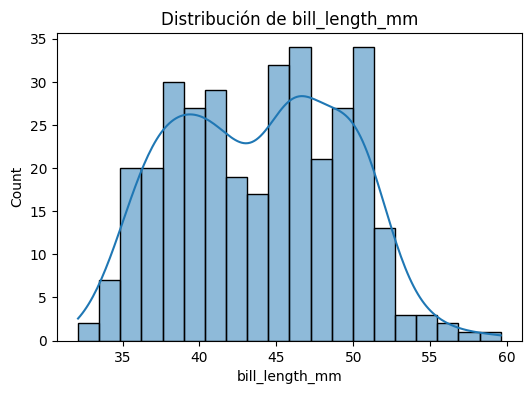

In [14]:
# Punto 11
# Histograma de bill_length
plt.figure(figsize=(6, 4))
sns.histplot(data=df, x='bill_length_mm', kde=True, bins=20)
plt.title(f'Distribución de bill_length_mm')
plt.show()

El histograma nos muestras que los datos siguen una una distribución bimodal. La curva no forma una sola campana de Gauss, sino que tiene dos picos. Esto es una señal de que hay diferentes especies mezcladas en la variable.

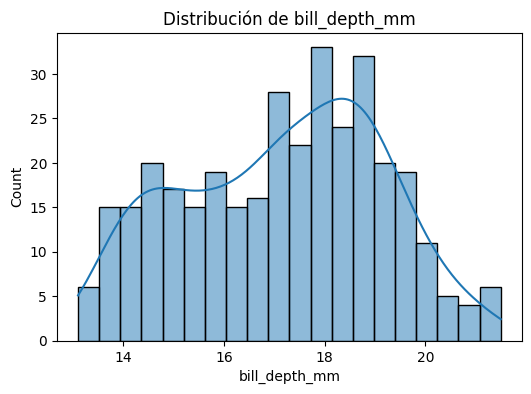

In [15]:
# Histograma de bill_depth
plt.figure(figsize=(6, 4))
sns.histplot(data=df, x='bill_depth_mm', kde=True, bins=20)
plt.title(f'Distribución de bill_depth_mm')
plt.show()

Este histograma también es bimodal. Muestra una separación evidente entre un grupo de pingüinos con picos más delgados y otro con picos más gruesos.

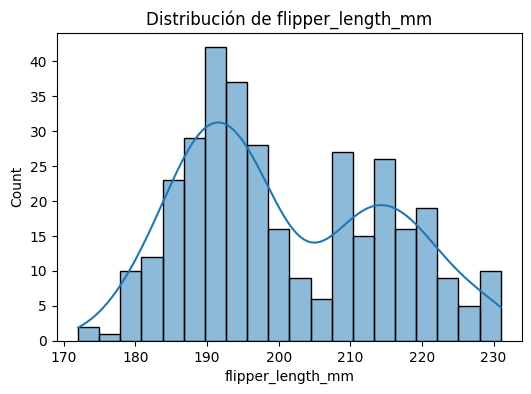

In [16]:
# Histograma de flipper
plt.figure(figsize=(6, 4))
sns.histplot(data=df, x='flipper_length_mm', kde=True, bins=20)
plt.title(f'Distribución de flipper_length_mm')
plt.show()

El histograma nos presenta una distribucion bimoda demasiado pronunciada. Hay una concentración principal alrededor de los 190 mm y una segunda concentración superando los 210 mm.

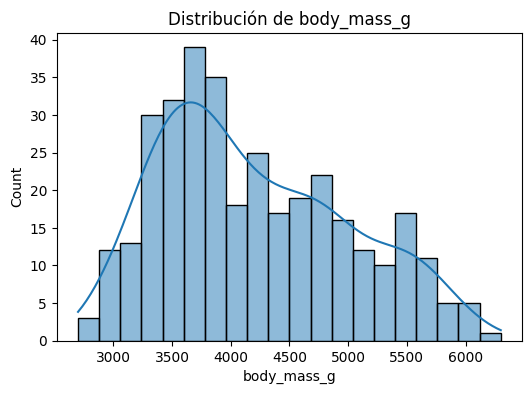

In [17]:
# Histograma de body mass
plt.figure(figsize=(6, 4))
sns.histplot(data=df, x='body_mass_g', kde=True, bins=20)
plt.title(f'Distribución de body_mass_g')
plt.show()

En este caso se presenta una distribución con asimetría positiva sesgada hacia la derecha. Tiene un gran pico principal en el rango de los 3500 a 4000 gramos, con una "cola" larga que desciende suavemente hacia los valores atípicos de pingüinos mucho más pesados,cerca de los 6000 gramos.

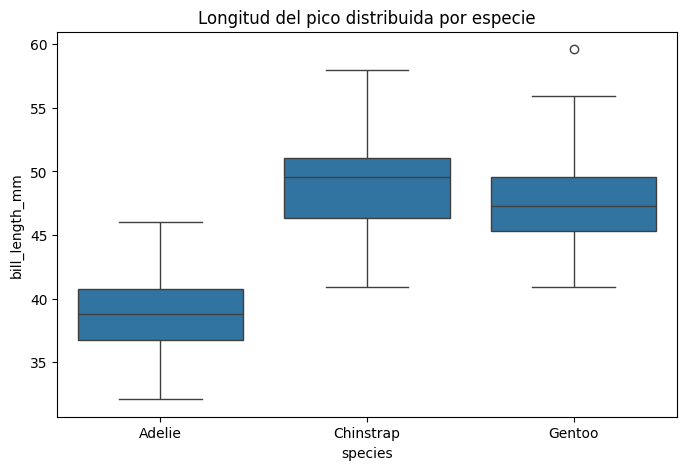

In [18]:
# Punto 12
# Boxplots
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='species', y='bill_length_mm')
plt.title('Longitud del pico distribuida por especie')
plt.show()

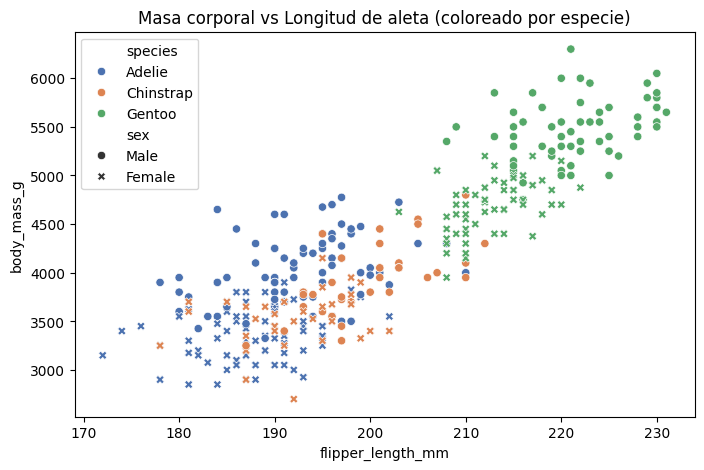

In [19]:
# Punto 13
# Scatter entre la masa corporal y longitud de ala coloreado por especie
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df,
                x='flipper_length_mm',
                y='body_mass_g',
                hue='species',
                style='sex',
                palette='deep')
plt.title('Masa corporal vs Longitud de aleta (coloreado por especie)')
plt.show()

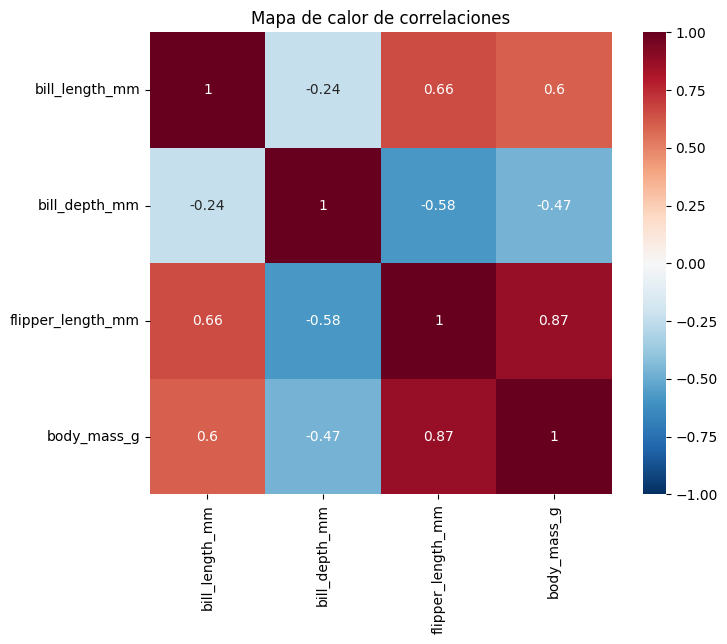

In [20]:
# Punto 14
# Heatmap de correlacion
# Usamos la matriz de correlación de Pearson
plt.figure(figsize=(8, 6))
matriz_corr = df.select_dtypes(include=['float64', 'int64']).corr()

sns.heatmap(matriz_corr, annot=True, cmap='RdBu_r', vmin=-1, vmax=1, square=True)
plt.title('Mapa de calor de correlaciones')
plt.show()

## Parte D

Hipótesis 1:

$H_0$ (Nula): La masa corporal y la longitud de la aleta son variables estadísticamente independientes.

$H_1$ (Alternativa): Existe una correlación entre la masa corporal y la longitud de la aleta en la población de pingüinos.

Hipótesis 2:

$H_0$ (Nula): La media de la longitud del pico es idéntica en las tres especies de pingüinos.

$H_1$ (Alternativa): Al menos una de las especies tiene una media de la longitud del pico distinta.

Hipótesis 3:

$H_0$ (Nula): La distribución de las especies de pingüinos es independiente de la isla en la que habitan.

$H_1$ (Alternativa): Existe una dependencia entre la especie de pinüinos y la isla, la probabilidad de encontrar una especie específica está condicionada por la isla.

## Parte E

Puntos 16, 17 y 18.

Para la primer hipotesis estamos comparando dos variables numericas continuas, la masa de los pingüinos y la longitud de sus aletas,debido a esto es necesario usar la correlación de Pearson, queremos saber si estas dos variables numericas tienen una correlacion lineal, es decir, si cuando aumenta una la otra lo hace tambien.

In [21]:
# --- H1: Pearson ---
df_clean = df.dropna(subset=['body_mass_g', 'flipper_length_mm'])
# Usamos sp_stats en lugar de stats
r_stat, p_val_1 = sp_stats.pearsonr(df_clean['body_mass_g'], df_clean['flipper_length_mm'])

print("--- H1: Masa vs Longitud de aleta ---")
print(f"Valor de Pearson (r): {r_stat:.4f}")
print(f"P-valor: {p_val_1:.4e}\n")

--- H1: Masa vs Longitud de aleta ---
Valor de Pearson (r): 0.8712
P-valor: 4.3707e-107



Los resultados del test nos muestran que, primero, existi una correlacion muy alta, r = 0.87, y segundo el P-valor es practicamente cero, muchisimo menor a 0.05, por lo que rechazamos la hipotesis nula y podemos afirmar que existe una correlación linal significativa entre el peso y la longitud de la aleta de los pingüinos, los pingüinos mas pesados tienen aletas mas largas.

Para la segunda hipotesis queremos comparar las medias de una variable numerica entre tres grupos categoricos, que son las especies de los pingüinos, dado que son tres variables numericas debemos usar la prueba ANOVA, si fueran dos podriamos usar el T-test.

In [22]:
# --- H2: ANOVA ---
adelie = df[df['species'] == 'Adelie']['bill_length_mm'].dropna()
chinstrap = df[df['species'] == 'Chinstrap']['bill_length_mm'].dropna()
gentoo = df[df['species'] == 'Gentoo']['bill_length_mm'].dropna()

# Usamos sp_stats en lugar de stats
f_stat, p_val_2 = sp_stats.f_oneway(adelie, chinstrap, gentoo)

print("--- H2: Longitud del pico por especie ---")
print(f"Valor de F: {f_stat:.4f}")
print(f"P-valor: {p_val_2:.4e}\n")

--- H2: Longitud del pico por especie ---
Valor de F: 410.6003
P-valor: 2.6946e-91



El valor tan alto de F = 410.60 nos indica que la variación de la longitud del pico entre los grupos de especies es mucho mayor que la variación de esta dentro de cada especie, y nuevamente el P-valor es practicamente cero, menor a 0.05, por lo que rechazamos la hipotesis nula y afirmamos que al menos una de las especies tiene una media de longitud dde pico diferente a las demás.

Para nuestra tercer hipotesis queremos estudiar la relación entre dos variables categóricas, la especie y la isla, queremos comparar las frecuencias observadas, es decir, cuantos pingüinos de cada especie hay en cada isla, con las frecuencias que obtendriamos si las variables fueran totalmente independientes, por lo que debemos usar el test de Chi-cuadrado.

In [23]:
# --- H3: Chi-cuadrado ---
tabla_frecuencias = pd.crosstab(df['species'], df['island'])

# Usamos sp_stats en lugar de stats
chi2_stat, p_val_3, dof, expected = sp_stats.chi2_contingency(tabla_frecuencias)

print("--- H3: Especie vs Isla ---")
print(f"Chi-cuadrado: {chi2_stat:.4f}")
print(f"P-valor: {p_val_3:.4e}\n")

--- H3: Especie vs Isla ---
Chi-cuadrado: 299.5503
P-valor: 1.3546e-63



El valor alto del Chi-cuadrado = 299.6 nos indica que hay mucha diferencia entre las frecuencias observadas y las frecuencias esperadas si las variables fueran independientes, además el P-valor nuevamente es muchisimo menor a 0.05, por lo que nuevamente rechazamos la hipotesis nula y afirmamos que la especie de pingüino y la isla en que habitan son variables dependientes, la especie de estos depende de la isla que se observe.

## Parte F

## Conclusiones y reporte

### A) Hallazgos descriptivos

La baja cardinalidad de las variables categóricas y una baja tasa de valores faltantes, con apenas 2 en dimensiones físicas y 11 en la variable de sexo, garantizan la validez del dataset y de el analisis estadistico realizado. Es importante la simetría tan grande entre machos (50.4%) y hembras (49.5%) analizados, esto descarta la existencia de sesgos de muestreo por género. Sin embargo, se encontro una alta variabilidad en los datos morfologicos, particularmente en la masa corporal, presentando una amplia desviación estándar de 801 g comparada con una media de 4201 g.

La matriz de contingencia nos muestra un comportamiento geográfico muy importante, la especie Gentoo (36.04% de la muestra) habita únicamente en la isla Biscoe, y la especie Chinstrap (19.76%) está restringida a la isla Dream, en contraste, Adelie (44.18%) se muestra presente en todas las islas estudiadas. Esta dependencia espacial quedó comprobada mediante la prueba Chi-cuadrado (p-valor = 1.35e-63), la cual rechaza la independencia entre la especie y su hábitat.

Finalmente, se encontro que el desarrollo físico de estas aves siguen comportamientos predecibles. La prueba de correlación de Pearson (r = 0.87, p-valor ≈ 0) muestra que la masa corporal y la longitud de la aleta crecen a la par bajo una dependencia lineal una de la otra. Por otro lado, la prueba de varianza ANOVA evidencia que las diferencias en las dimensiones físicas, tales como el tamaño del pico, no se deben a eventos aleatorios, sino que representan marcadores morfológicos que definen e independizan cada una de las especies estudiadas.

### B) Patrones visuales

Los histogramas correspondientes a la longitud y profundidad del pico, así como a la longitud de la aleta, muestran patrones bimodales, este comportamiento evidencia que la muestra no obedece a una única distribución continua, sino a la superposición de subgrupos con características morfométricas diferentes. Además la distribución de la masa corporal presenta un sesgo positivo, mostrando una subpoblación de individuos con dimensiones corporales atípicamente superiores al promedio.

Los diagramas de caja nos muestran que al analizar la longitud del pico, la especie Adelie es muy diferente de las demas, teniendo una mediana alrededor de 39 mm, separándose drásticamente de los rangos de Gentoo y Chinstrap.

Finalmente, el diagrama de dispersión para aleta vs. masa actúa como la síntesis definitiva de esta dinámica poblacional. En el plano cartesiano, la especie Gentoo esta completamente aislada, por el contrario, Adelie y Chinstrap coexisten. En el mapa de calor, las intensidades confirman esto.

### C) Próximas hipótesis a probar

Las hipotesis que se podrian formular a partir de lo encontrado pueden ser:

- **Dimorfismo Sexual:** El peso y las dimensiones morfologicas de los pingüinos, como la profundidad del pico, presentan una diferencia estadísticamente significativa entre machos y hembras. Se puede probar usando T-test independiente.
- **Competencia Ecológica:** Existe un factor ambiental o de competencia de recursos que impide que las especies Gentoo y Chinstrap compartan la misma isla, se puede probar si la disponibilidad de espacio determina la especie.

### 20) Preguntas para un investigador

Siguiendo esta investigación y lo mostrado por el dataset se podrian realizar las siguientes preguntas:

1. Dado que los pingüinos Gentoo estan en la isla Biscoe, ¿debemos considerar a la "isla" como una variable determinista? ¿Son los Gentoo más grandes por su genética, o la isla Biscoe tiene recursos alimenticios que propician tamaños mas grandes a estos pingüinos?
2. Estadísticamente, confirmamos que Gentoo y Chinstrap no comparten islas en absoluto en esta muestra. ¿Hay barreras físicas, diferencias de dieta o territorialidad agresiva que expliquen esta separación?